In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import os

In [43]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# ── Configurations ─────────

In [44]:
TICKER = "AAPL"
 
PERIOD    = "16y"
TRAIN_PCT = 0.8     # 80% train, 20% test

FEATURES = [       # the 10 features — input to the LSTM
    "return",
    "lag1",
    "lag5",
    "lag10",
    "ma10",
    "ma50",
    'price_vs_ma50',
    'high_low_range',
    "volatility5",
    "volatility10",
    "volatility20",
    "volatility60",
    'vol_ratio',
    "rsi",
    "macd",
    'volume_change',
    "volume_ratio"
]
TARGET = "volatility20"   # what we predict

In [45]:
len(FEATURES)

17

# ────── feature enginering ───────

In [46]:
from functions import load_ticker

data = load_ticker(TICKER, PERIOD)

[*********************100%***********************]  1 of 1 completed


# ── Train / test split ─────────

In [47]:
from functions import split_data

train_data, test_data = split_data(data, TRAIN_PCT)

train=792 rows, test=3173 rows, split date=2013-09-06


# ── Visualization ─────────

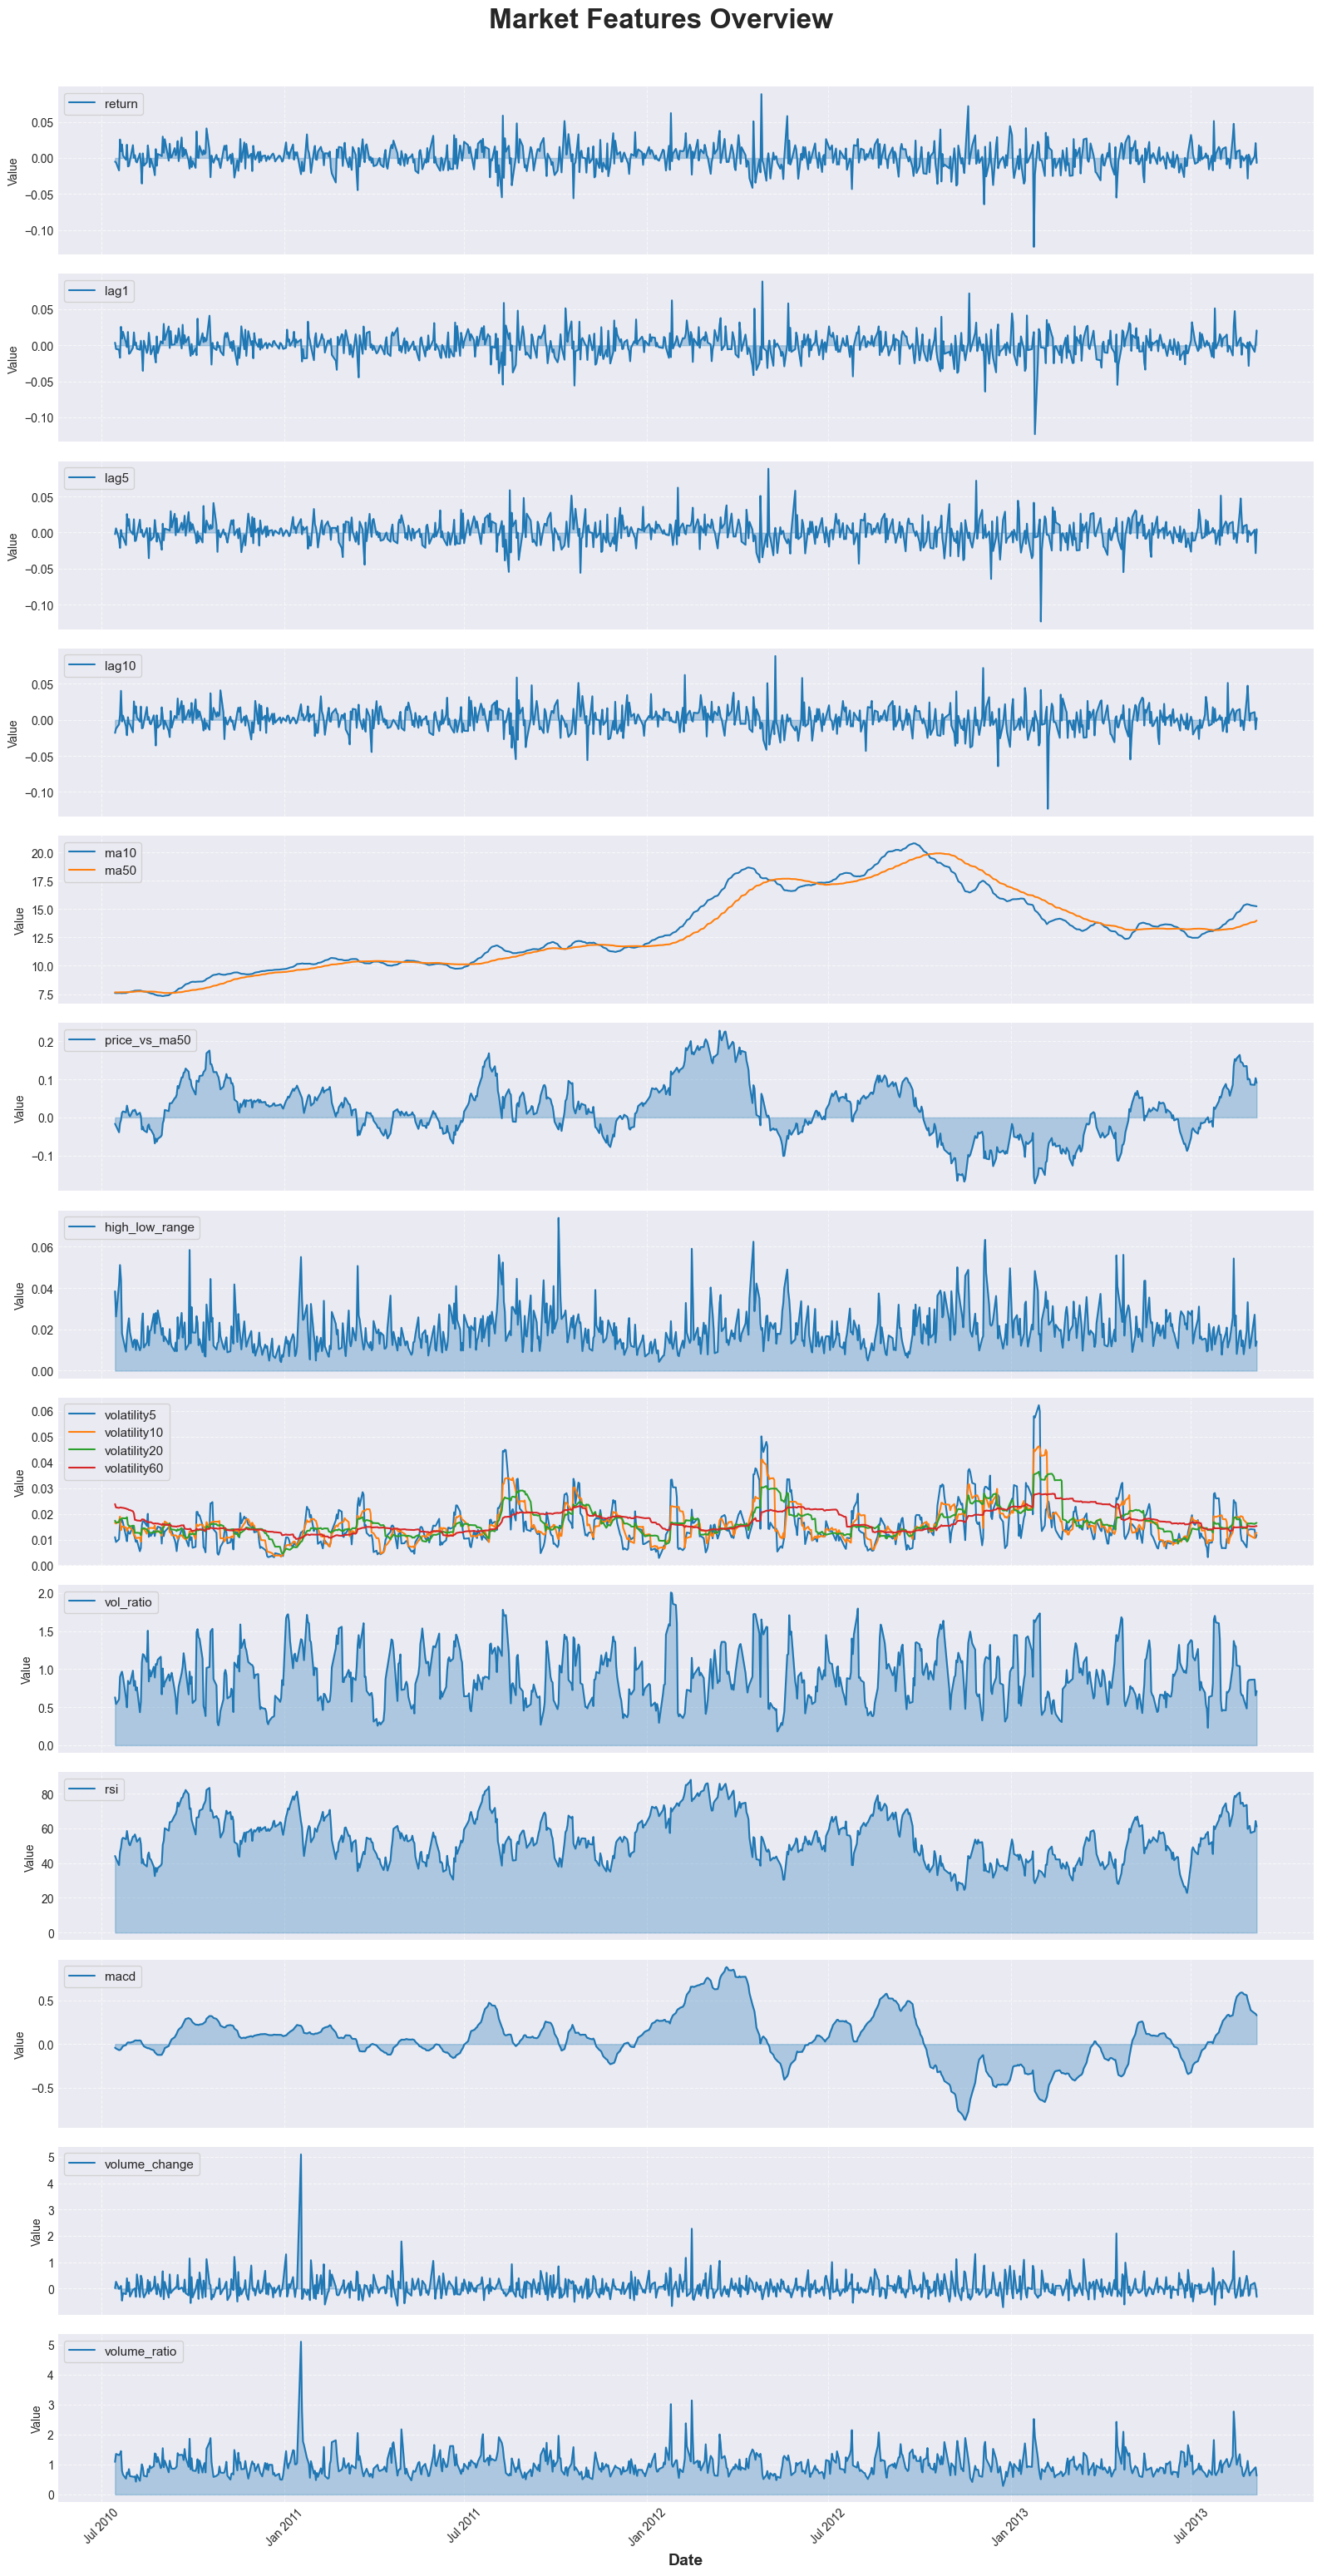

In [48]:
train_data.index = pd.to_datetime(train_data.index)

plot_groups = [
    ["return"],
    ["lag1"],
    ["lag5"],
    ["lag10"],
    ["ma10", "ma50"], 
    ['price_vs_ma50'],
    ['high_low_range'],
    ["volatility5", "volatility10", "volatility20", "volatility60"], 
    ['vol_ratio'],
    ["rsi"],
    ["macd"],
    ['volume_change'],
    ["volume_ratio"]
]

# Visualization Setup
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(nrows=13, ncols=1, figsize=(16, 34), sharex=True)
fig.suptitle('Market Features Overview', fontsize=24, fontweight='bold', y=0.91)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Plotting Loop
for i, (ax, group) in enumerate(zip(axes, plot_groups)):
    for j, feature in enumerate(group):
        color = colors[j % len(colors)]
        
        if len(group) == 1:
            ax.fill_between(train_data.index, train_data[feature], alpha=0.3, color=color)
            
        ax.plot(train_data.index, train_data[feature], label=feature, color=color, linewidth=1.5)
    
    ax.legend(loc='upper left', frameon=True, fontsize=11)
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- FIX 2: Force Matplotlib to limit the number of X-axis ticks ---
axes[-1].set_xlabel('Date', fontsize=14, fontweight='bold')

# Automatically pick the best dates to show, keeping it to around 10 max
locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
axes[-1].xaxis.set_major_locator(locator)

# Format them nicely (e.g., 'Jan 2023')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [49]:
class StockDataset(Dataset):
    """
    Simple PyTorch Dataset wrapper around our numpy arrays.
    Converts them to float32 tensors and moves to device.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [50]:
from functions import make_windows, fit_scaler, apply_scaler

def Transformation_Pipeline(data : pd.DataFrame, test_pct : float, val_pct : float, W : int, features : list, target : str, BatchSize : int, scaler_name : str, save_scaler : bool = True) -> tuple:

    train_data, test_data = split_data(data, test_pct=test_pct)
    train_data, val_data = split_data(train_data, test_pct=val_pct)

    X_train, y_train = make_windows(train_data, W=W, features=features, target=target)
    X_val, y_val = make_windows(val_data, W=W, features=features, target=target)
    X_test, y_test = make_windows(test_data, W=W, features=features, target=target)

    scaler = fit_scaler(X_train=X_train)

    X_train_scaled = apply_scaler(X_train, scaler=scaler)
    X_val_scaled = apply_scaler(X_val, scaler=scaler)
    X_test_scaled = apply_scaler(X_test, scaler=scaler)

    if save_scaler:
        joblib.dump(scaler, f"../models/"+scaler_name+".pkl")

    train_loader = DataLoader(StockDataset(X_train_scaled, y_train), batch_size=BatchSize, shuffle=True)
    val_loader = DataLoader(StockDataset(X_val_scaled, y_val), batch_size=BatchSize, shuffle=False,)
    test_loader = DataLoader(StockDataset(X_test_scaled, y_test), batch_size=BatchSize, shuffle=False)

    return (train_loader, val_loader, test_loader)

# ──────────  Trainig the Model  ──────────
the best part ^_^

In [51]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE   # lenovo legion with RTX 4060 ^_^

device(type='cuda')

# ── Model ^_^ ─────────

# ───── LSTM ──────

## ── Hyperparameters ───────────

In [ ]:
# these are starting values, we will tune them later
HIDDEN_SIZE_LSTM = 64      
NUM_LAYERS_LSTM = 2        
DROPOUT_LSTM = 0.13425006919751267  
LEARNING_RATE_LSTM = 0.0020733744699150854
BATCH_SIZE_LSTM = 48
EPOCHS_LSTM = 100
PATIENCE_LSTM = 23
W_LSTM = 60
quantile_LSTM = 0.6176637604495911

In [53]:
class StockLSTM(nn.Module):
    """
    LSTM model for stock return prediction.
 
    Architecture:
        Input  → LSTM layers → Dropout → Linear → Output
 
    Input shape:  (batch_size, W, n_features)
    Output shape: (batch_size, 1)
    """
    def __init__(self, n_features: int, hidden_size: int, num_layers: int, dropout: float):
        super(StockLSTM, self).__init__()

        # self.softplus = nn.Softplus()
 
        self.lstm = nn.LSTM(
            input_size   = n_features,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0,  # dropout only between layers
            batch_first  = True    # input shape: (batch, seq, features)
        )
 
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_size, 1)
 
    def forward(self, x):
        # x shape: (batch_size, W, n_features)
 
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch_size, W, hidden_size)
 
        # take only the last timestep's output
        # because we want to predict the next day after the sequence ends
        last_out = lstm_out[:, -1, :]
        # last_out shape: (batch_size, hidden_size)
 
        out = self.dropout(last_out)
        out = self.linear(out)
        # out = self.softplus(out)
        # out shape: (batch_size, 1)
 
        return out.squeeze(1)   # shape: (batch_size,)

# ───── GRU ──────

## ── Hyperparameters ───────────

In [ ]:
# these are starting values, we will tune them later
HIDDEN_SIZE_GRU = 256       
NUM_LAYERS_GRU = 4        
DROPOUT_GRU = 0.5049696839451802      
LEARNING_RATE_GRU = 0.001423301166151796
BATCH_SIZE_GRU = 32
EPOCHS_GRU = 100
PATIENCE_GRU = 20
W_GRU = 50
quantile_GRU = 0.6413430231856577

In [55]:
class StockGRU(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0,
            batch_first = True
        )
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_out   = gru_out[:, -1, :]
        out        = self.dropout(last_out)
        out        = self.linear(out)
        return out.squeeze(1)

In [56]:
def quantile_loss(preds, target, quantile=0.68):
    """
    Calculate the pinball/quantile loss.
    quantile: float between 0 and 1 (e.g., 0.9 for the 90th percentile).
    """
    errors = target - preds
    loss = torch.max((quantile - 1) * errors, quantile * errors)
    return loss.mean()

# ── Training loop ──────────

In [57]:
def train_model(model, train_loader, val_loader, epochs, lr, patience, quantile, device):
    """
    Trains the model and returns train/val loss history.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # criterion = nn.MSELoss()
 
    # reduce learning rate if validation loss plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
 
    train_losses = []
    val_losses   = []
    best_val_loss = float("inf")
    best_weights  = None
    
    patience_counter = 0

    for epoch in range(1, epochs + 1):
 
        # ── training phase
        model.train()
        batch_losses = []
 
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
 
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = quantile_loss(predictions, y_batch, quantile=quantile)
            loss.backward()
 
            # gradient clipping — prevents exploding gradients in LSTMs
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
 
            optimizer.step()
            batch_losses.append(loss.item())
 
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)
 
        # ── validation phase
        model.eval()
        val_batch_losses = []
 
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                predictions = model(X_batch)
                loss = quantile_loss(predictions, y_batch, quantile=quantile)
                val_batch_losses.append(loss.item())
 
        val_loss = np.mean(val_batch_losses)
        val_losses.append(val_loss)
 
        # update learning rate scheduler
        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr < prev_lr:
            print(f"  → learning rate reduced to {new_lr:.2e}")
 
        # save best weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch}")
                break
 
        # if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} — "
              f"train loss: {train_loss:.6f} — "
              f"val loss: {val_loss:.6f}")    
 
    # restore best weights
    model.load_state_dict(best_weights)
    print(f"\nBest val loss: {best_val_loss:.6f}")
 
    return train_losses, val_losses

# ── Evaluation ──────────

In [58]:
from sklearn.metrics import root_mean_squared_error

def evaluate_model(model, loader, device):
    """
    Returns predictions and true values for a dataset.
    Also computes RMSE and directional accuracy.
    """
    model.eval()
    all_preds = []
    all_true  = []
 
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds   = model(X_batch).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
 
    preds = np.array(all_preds)
    true  = np.array(all_true)
 
    rmse = root_mean_squared_error(true, preds)
 
    return preds, true, rmse

# Training and Evaluate the LSTM

In [59]:
# ── create dataloaders
train_loader, val_loader, test_loader = Transformation_Pipeline(
    data=data,
    test_pct=0.2,
    val_pct=0.1,
    W=W_LSTM,
    features=FEATURES,
    target=TARGET,
    BatchSize=BATCH_SIZE_LSTM,
    scaler_name='scaler_LSTM'
)

train=3172 rows, test=793 rows, split date=2023-02-21
train=2854 rows, test=318 rows, split date=2021-11-12
number of instances : 2794
number of instances : 258
number of instances : 733


In [86]:
# ── build model
n_features = len(FEATURES)
model_LSTM = StockLSTM(
    n_features = n_features,
    hidden_size = HIDDEN_SIZE_LSTM,
    num_layers = NUM_LAYERS_LSTM,
    dropout = DROPOUT_LSTM
).to(DEVICE)

In [61]:
model_LSTM

StockLSTM(
  (lstm): LSTM(17, 64, num_layers=2, batch_first=True, dropout=0.13425006919751267)
  (dropout): Dropout(p=0.13425006919751267, inplace=False)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

In [62]:
total_params = sum(p.numel() for p in model_LSTM.parameters())
total_params

54593

In [87]:
Finish = False

while not Finish:
    # ── train
    train_losses, val_losses = train_model(
        model_LSTM, train_loader, val_loader,
        epochs=EPOCHS_LSTM, lr=LEARNING_RATE_LSTM, 
        patience=PATIENCE_LSTM, device=DEVICE, quantile=quantile_LSTM
    )

    preds, true, rmse = evaluate_model(model_LSTM, test_loader, DEVICE)

    # compare your model vs pure persistence
    persistence_preds = true[:-1]   # today's vol as prediction for tomorrow
    persistence_true  = true[1:]

    persistence_rmse     = root_mean_squared_error(persistence_true, persistence_preds)
    persistence_relative = persistence_rmse / persistence_true.mean()
    Improvement = persistence_relative - rmse/true.mean()

    if Improvement > 0:
        Finish = True
    else:
        model_LSTM = StockLSTM(
            n_features = n_features,
            hidden_size = HIDDEN_SIZE_LSTM,
            num_layers = NUM_LAYERS_LSTM,
            dropout = DROPOUT_LSTM
        ).to(DEVICE)
        print('Retraining')


Epoch   1/100 — train loss: 0.004758 — val loss: 0.001302
Epoch   2/100 — train loss: 0.001902 — val loss: 0.001013
Epoch   3/100 — train loss: 0.001361 — val loss: 0.001034
Epoch   4/100 — train loss: 0.001026 — val loss: 0.000699
Epoch   5/100 — train loss: 0.000874 — val loss: 0.001054
Epoch   6/100 — train loss: 0.000789 — val loss: 0.000711
Epoch   7/100 — train loss: 0.000620 — val loss: 0.000505
Epoch   8/100 — train loss: 0.000592 — val loss: 0.000582
Epoch   9/100 — train loss: 0.000589 — val loss: 0.000586
Epoch  10/100 — train loss: 0.000542 — val loss: 0.000735
Epoch  11/100 — train loss: 0.000506 — val loss: 0.000512
Epoch  12/100 — train loss: 0.000512 — val loss: 0.000453
Epoch  13/100 — train loss: 0.000503 — val loss: 0.000678
Epoch  14/100 — train loss: 0.000517 — val loss: 0.000458
Epoch  15/100 — train loss: 0.000498 — val loss: 0.000635
Epoch  16/100 — train loss: 0.000468 — val loss: 0.000461
Epoch  17/100 — train loss: 0.000509 — val loss: 0.000427
Epoch  18/100 

In [64]:
preds, true, rmse = evaluate_model(model_LSTM, test_loader, DEVICE)

In [65]:
print(f"RMSE          : {rmse:.6f}")
print(f"Mean vol      : {true.mean():.6f}")
print(f"Relative error: {rmse / true.mean():.2%}")

RMSE          : 0.001409
Mean vol      : 0.014754
Relative error: 9.55%


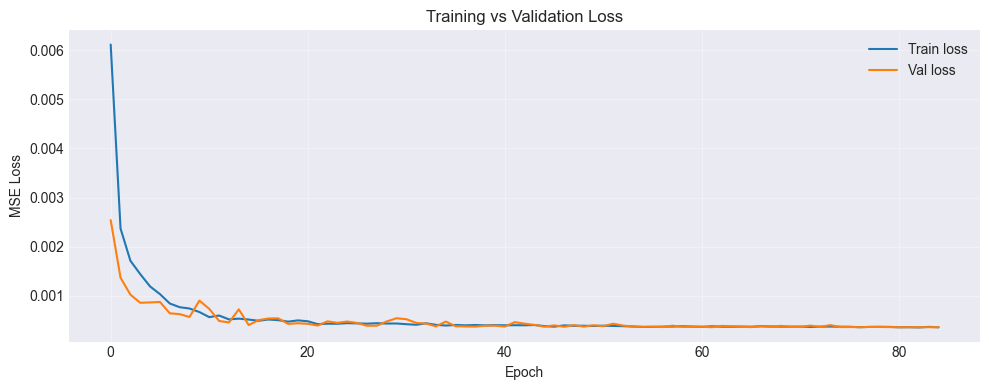

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

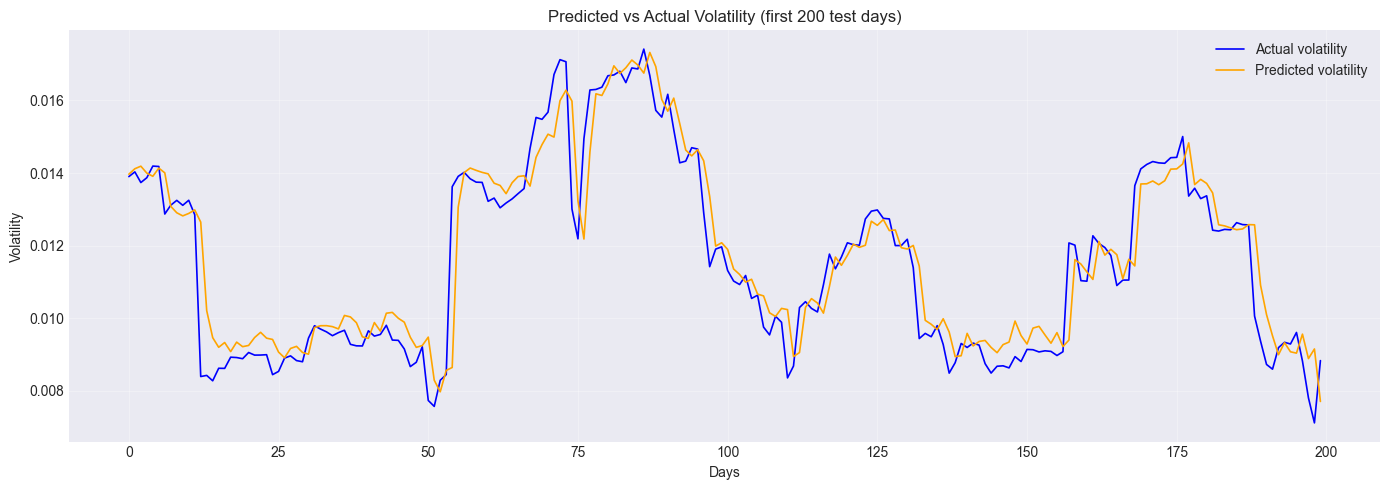

In [67]:
plt.figure(figsize=(14, 5))
plt.plot(true[:200],  label='Actual volatility',    color='blue',   linewidth=1.2)
plt.plot(preds[:200], label='Predicted volatility', color='orange', linewidth=1.2)
plt.title('Predicted vs Actual Volatility (first 200 test days)')
plt.xlabel('Days')
plt.ylabel('Volatility')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
# compare your model vs pure persistence
persistence_preds = true[:-1]   # today's vol as prediction for tomorrow
persistence_true  = true[1:]

persistence_rmse     = root_mean_squared_error(persistence_true, persistence_preds)
persistence_relative = persistence_rmse / persistence_true.mean()

print(f"LSTM          : {rmse/true.mean():.2%}")
print(f"Persistence   : {persistence_relative:.2%}")
print(f"Improvement   : {persistence_relative - rmse/true.mean():.2%}")

LSTM          : 9.55%
Persistence   : 9.63%
Improvement   : 0.08%


In [69]:
actual_change = true[1:] - true[:-1]
predicted_change = preds[1:] - true[:-1]

# 2. Check where the signs match (both up or both down)
correct_direction = np.sign(actual_change) == np.sign(predicted_change)

# 3. Calculate hit ratio
hit_ratio = np.mean(correct_direction)

print(f"Directional Hit Ratio: {hit_ratio:.2%}")

Directional Hit Ratio: 56.28%


In [ ]:
# torch.save(model_LSTM.state_dict(), '../models/model_weights_LSTM.pth')

# LSTM END

# Training and Evaluate the GRU

In [71]:
# ── create dataloaders
train_loader, val_loader, test_loader = Transformation_Pipeline(
    data=data,
    test_pct=0.2,
    val_pct=0.1,
    W=W_GRU,
    features=FEATURES,
    target=TARGET,
    BatchSize=BATCH_SIZE_GRU,
    scaler_name='scaler_GRU'
)

train=3172 rows, test=793 rows, split date=2023-02-21
train=2854 rows, test=318 rows, split date=2021-11-12
number of instances : 2804
number of instances : 268
number of instances : 743


In [72]:
# ── build model
n_features = len(FEATURES)
model_GRU = StockGRU(
    n_features = n_features,
    hidden_size = HIDDEN_SIZE_GRU,
    num_layers = NUM_LAYERS_GRU,
    dropout = DROPOUT_GRU
).to(DEVICE)

In [73]:
model_GRU

StockGRU(
  (gru): GRU(17, 256, num_layers=4, batch_first=True, dropout=0.5049696839451802)
  (dropout): Dropout(p=0.5049696839451802, inplace=False)
  (linear): Linear(in_features=256, out_features=1, bias=True)
)

In [74]:
total_params = sum(p.numel() for p in model_GRU.parameters())
total_params

1395713

In [75]:
# ── train
train_losses, val_losses = train_model(
    model_GRU, train_loader, val_loader,
    epochs=EPOCHS_GRU, lr=LEARNING_RATE_GRU, 
    patience=PATIENCE_GRU, device=DEVICE, quantile=quantile_GRU
)

Epoch   1/100 — train loss: 0.011536 — val loss: 0.004169
Epoch   2/100 — train loss: 0.002828 — val loss: 0.001282
Epoch   3/100 — train loss: 0.001343 — val loss: 0.001335
Epoch   4/100 — train loss: 0.000989 — val loss: 0.001095
Epoch   5/100 — train loss: 0.000964 — val loss: 0.002093
Epoch   6/100 — train loss: 0.000983 — val loss: 0.000821
Epoch   7/100 — train loss: 0.000951 — val loss: 0.001234
Epoch   8/100 — train loss: 0.000935 — val loss: 0.001107
Epoch   9/100 — train loss: 0.000896 — val loss: 0.000584
Epoch  10/100 — train loss: 0.000938 — val loss: 0.000689
Epoch  11/100 — train loss: 0.000911 — val loss: 0.000658
Epoch  12/100 — train loss: 0.000957 — val loss: 0.000903
Epoch  13/100 — train loss: 0.000990 — val loss: 0.002544
Epoch  14/100 — train loss: 0.000905 — val loss: 0.001504
  → learning rate reduced to 7.12e-04
Epoch  15/100 — train loss: 0.000907 — val loss: 0.000670
Epoch  16/100 — train loss: 0.000758 — val loss: 0.000598
Epoch  17/100 — train loss: 0.0007

In [76]:
preds, true, rmse = evaluate_model(model_GRU, test_loader, DEVICE)

In [77]:
print(f"RMSE          : {rmse:.6f}")
print(f"Mean vol      : {true.mean():.6f}")
print(f"Relative error: {rmse / true.mean():.2%}")

RMSE          : 0.001398
Mean vol      : 0.014748
Relative error: 9.48%


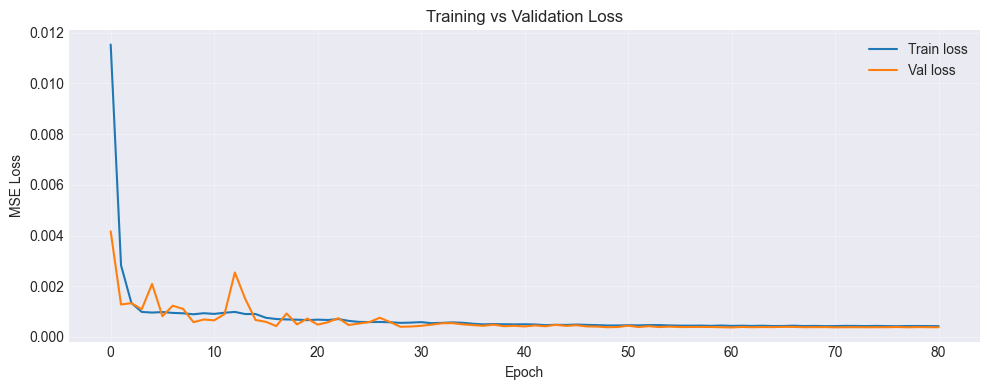

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

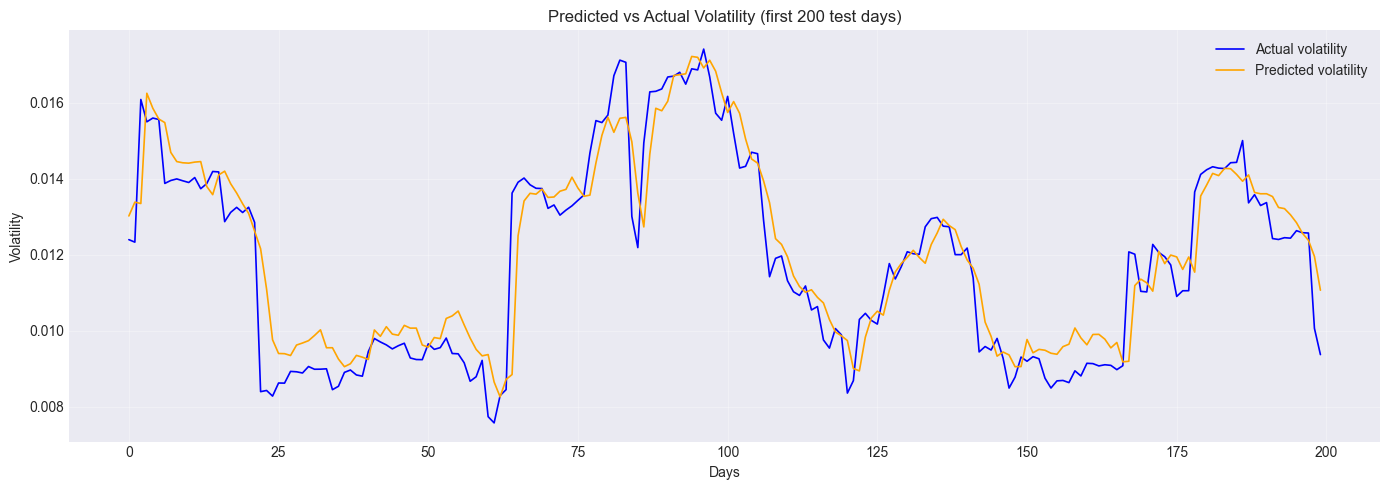

In [85]:
plt.figure(figsize=(14, 5))
plt.plot(true[:200],  label='Actual volatility',    color='blue',   linewidth=1.2)
plt.plot(preds[:200], label='Predicted volatility', color='orange', linewidth=1.2)
plt.title('Predicted vs Actual Volatility (first 200 test days)')
plt.xlabel('Days')
plt.ylabel('Volatility')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
# compare your model vs pure persistence
persistence_preds = true[:-1]   # today's vol as prediction for tomorrow
persistence_true  = true[1:]

persistence_rmse     = root_mean_squared_error(persistence_true, persistence_preds)
persistence_relative = persistence_rmse / persistence_true.mean()

print(f"GRU           : {rmse/true.mean():.2%}")
print(f"Persistence   : {persistence_relative:.2%}")
print(f"Improvement   : {persistence_relative - rmse/true.mean():.2%}")

GRU           : 9.48%
Persistence   : 9.63%
Improvement   : 0.15%


In [81]:
actual_change = true[1:] - true[:-1]
predicted_change = preds[1:] - true[:-1]

# 2. Check where the signs match (both up or both down)
correct_direction = np.sign(actual_change) == np.sign(predicted_change)

# 3. Calculate hit ratio
hit_ratio = np.mean(correct_direction)

print(f"Directional Hit Ratio: {hit_ratio:.2%}")

Directional Hit Ratio: 56.87%


In [ ]:
# torch.save(model_GRU.state_dict(), '../models/model_weights_GRU.pth')